In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12,6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 관련
# 결측치 처리
from sklearn.impute import SimpleImputer

### 이상치 처리
- 다른 값들과 너무 차이가 많이 나는 값들을 의미한다
- 확인 방법1) Boxplot을 통해 확인할 수 있다.
- 확인 방법2) IQR을 통해 극단치 경계를 구해서 확인할 수 있다.
- 데이터 : IT 스타트업 개발자 100명의 연봉 데이터
- 정상 범위 : 대략 4000만원 ~ 8000만원 사이
- 이상치 : 갑자기 연봉 10억원을 받는 외부 고문 2명이 데이터에 포함된다.
- 문제 : 이 2명 때문에 회사 평균 연봉이 비현실적으로 높아지게 된다.
- 해결 : 극단치를 찾아서 처리한다.

In [2]:
# 데이터를 생성한다.
np.random.seed(42)
# 정상데이터 : 평균 5000, 표준편차 1000인 100명
normal_salary = np.random.normal(loc=5000, scale=1000, size=100)
normal_salary

array([5496.71415301, 4861.73569883, 5647.6885381 , 6523.02985641,
       4765.84662528, 4765.86304305, 6579.21281551, 5767.43472915,
       4530.52561407, 5542.56004359, 4536.58230719, 4534.27024643,
       5241.96227157, 3086.71975534, 3275.08216749, 4437.71247076,
       3987.16887967, 5314.2473326 , 4091.97592448, 3587.69629866,
       6465.64876892, 4774.22369951, 5067.52820469, 3575.25181379,
       4455.61727547, 5110.92258971, 3849.00642258, 5375.69801835,
       4399.36131008, 4708.30625021, 4398.29338777, 6852.27818451,
       4986.50277526, 3942.28907104, 5822.5449121 , 3779.15635003,
       5208.863595  , 3040.32987612, 3671.8139511 , 5196.86123587,
       5738.46658   , 5171.36828119, 4884.35171761, 4698.89630441,
       3521.47800963, 4280.15579161, 4539.36122904, 6057.12222622,
       5343.61828957, 3236.95984464, 5324.08396939, 4614.91771958,
       4323.07799969, 5611.67628884, 6030.9995225 , 5931.28011912,
       4160.78247678, 4690.78762415, 5331.2634314 , 5975.54512

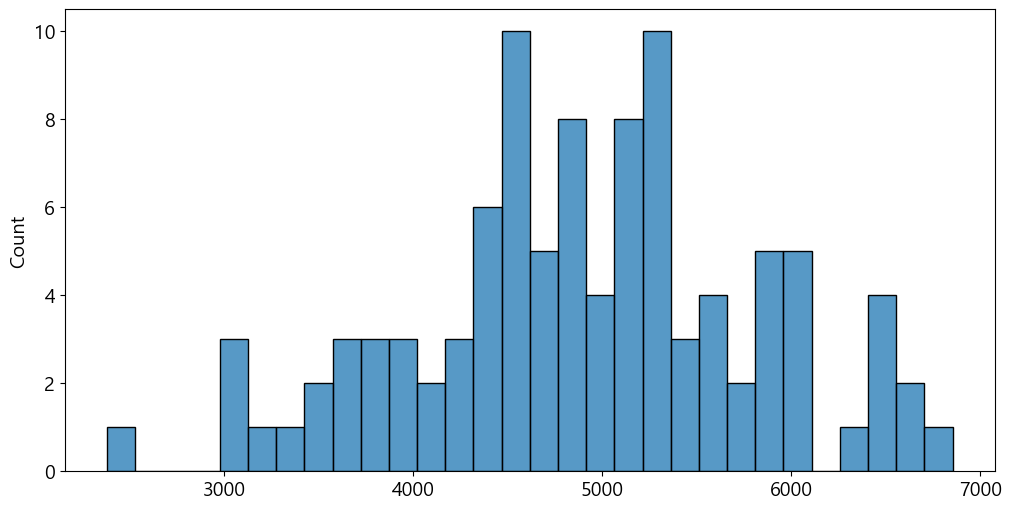

In [4]:
sns.histplot(normal_salary, bins=30)
plt.show()

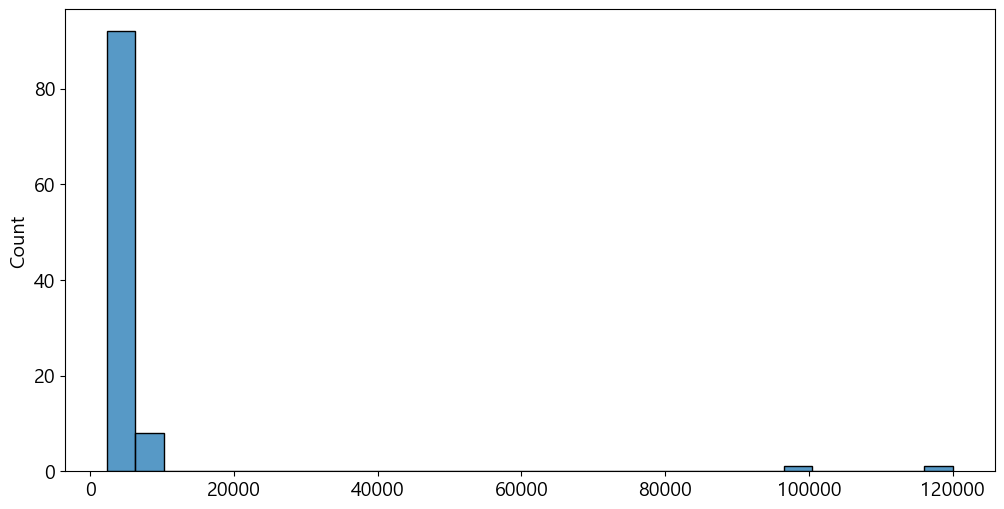

In [5]:
# 이상치 데이터
outliers = np.array([100000,120000])
salary_data = np.concatenate([normal_salary, outliers])
sns.histplot(salary_data,bins=30)
plt.show()

In [7]:
df = pd.DataFrame(salary_data, columns=['연봉(만원)'])
df

,연봉(만원)
0,5496.714153
1,4861.735699
2,5647.688538
3,6523.029856
4,4765.846625
...,...
97,5261.055272
98,5005.113457
99,4765.412867
100,100000.000000


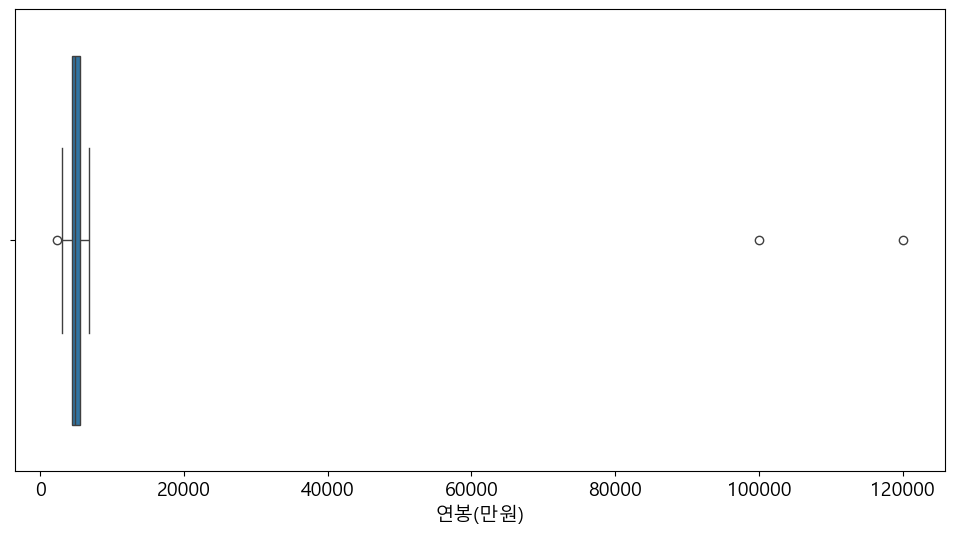

In [11]:
# BoxPlot을 통해 극단치 존재를확인한다.
sns.boxplot(df, x='연봉(만원)')
plt.show()

In [19]:
# 극단치 경계를 구해 극단치를 확인한다.
Q1 = df['연봉(만원)'].quantile(0.25)
Q3 = df['연봉(만원)'].quantile(0.75)
IQR = Q3 - Q1

# 극단치 경계
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

# 정상 범위의 데이터
df_clean = df[(df['연봉(만원)'] >= lower_bound) & (df['연봉(만원)']  <= upper_bound)]
df_clean

,연봉(만원)
0,5496.714153
1,4861.735699
2,5647.688538
3,6523.029856
4,4765.846625
...,...
95,3536.485052
96,5296.120277
97,5261.055272
98,5005.113457


In [21]:
# 비정상 범위의 데이터
df_outliner = df[(df['연봉(만원)'] < lower_bound) | (df['연봉(만원)']  > upper_bound)]
df_outliner

,연봉(만원)
74,2380.254896
100,100000.000000
101,120000.000000


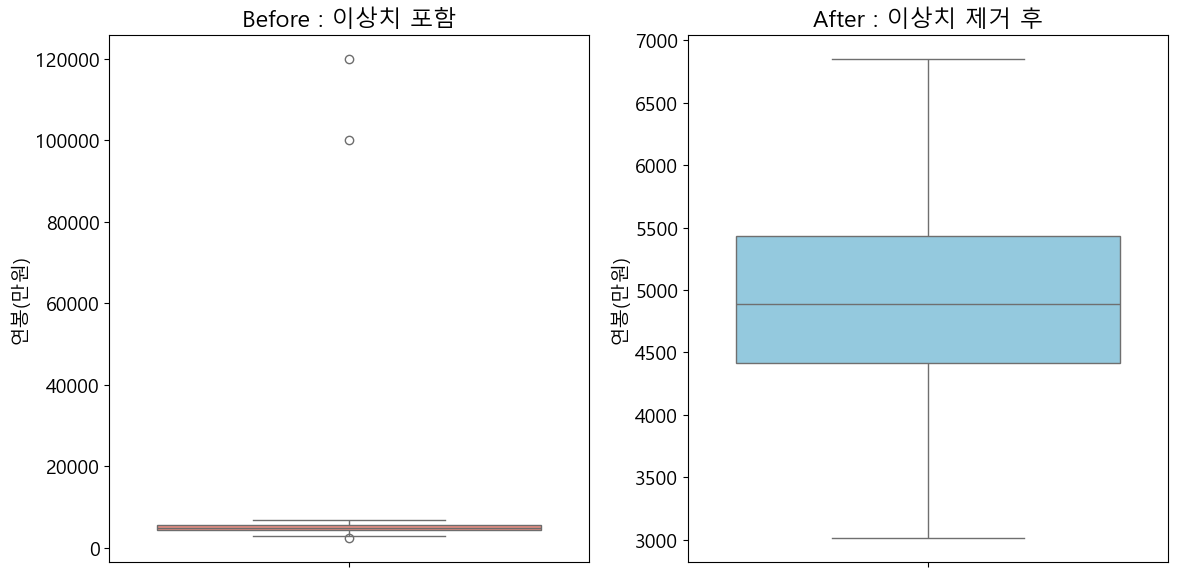

In [24]:
# 이상지 제거 전
plt.subplot(1,2,1)
sns.boxplot(data=df, y='연봉(만원)', color='salmon')
plt.title('Before : 이상치 포함')
#plt.ylim(0,130000)

# 이상치 제거 후
plt.subplot(1,2,2)
sns.boxplot(data=df_clean, y='연봉(만원)', color='skyblue')
plt.title('After : 이상치 제거 후')
#plt.ylim(0,130000)

plt.tight_layout()
plt.show()

In [27]:
print(f'이상치 제거 전 데이터 개수: {len(df)}')
print(f'이상치 제거 후 데이터 개수: {len(df_clean)}')
print(f'이상치 제거 전 평균 : {df['연봉(만원)'].mean():.2f}')
print(f'이상치 제거 후 평균 : {df_clean['연봉(만원)'].mean():.2f}')

이상치 제거 전 데이터 개수: 102
이상치 제거 후 데이터 개수: 99
이상치 제거 전 평균 : 6957.01
이상치 제거 후 평균 : 4921.57
